# SWaT Data Exploration

Explore the Secure Water Treatment System (SwaT) and adapts the original TranAD SMD analysis workflow to an industrial control system setting. The goal is to understand the data structure, visualize sensor behavior, and evaluate anomaly detection performance using the trained TranAD model.

In [7]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd()
for _ in range(5):
    if (PROJECT_ROOT / "pyproject.toml").exists():
        break
    PROJECT_ROOT = PROJECT_ROOT.parent

assert (PROJECT_ROOT / "pyproject.toml").exists(), "Could not find project root"
sys.path.insert(0, str(PROJECT_ROOT))

import logging
logging.getLogger("src").setLevel(logging.WARNING)

import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline

from src.preprocess import load_processed_swat_data

## Load Raw SWaT Data

Load the preprocessed SWaT training data, test data, and anomaly labels generated during the preprocessing stage. These datasets will be used for exploratory analysis and model evaluation. The dataset had 51 features

In [8]:
import pandas as pd

normal = pd.read_csv(PROJECT_ROOT / "data" / "swat" / "raw" / "normal.csv")
merged = pd.read_csv(PROJECT_ROOT / "data" / "swat" / "raw" / "merged.csv")

normal.columns = normal.columns.str.strip()
merged.columns = merged.columns.str.strip()

print(f"Normal shape: {normal.shape}")
print(f"Merged shape: {merged.shape}")

print("\nNormal basic statistics:")
print(f"  Rows: {len(normal):,}")
print(f"  Columns: {len(normal.columns)}")
print(f"  NaNs: {normal.isna().sum().sum()}")

print("\nMerged basic statistics:")
print(f"  Rows: {len(merged):,}")
print(f"  Columns: {len(merged.columns)}")
print(f"  NaNs: {merged.isna().sum().sum()}")

print("\nLabel distribution:")
print(merged["Normal/Attack"].astype(str).str.strip().value_counts())

Normal shape: (1387098, 53)
Merged shape: (1441719, 53)

Normal basic statistics:
  Rows: 1,387,098
  Columns: 53
  NaNs: 6942600

Merged basic statistics:
  Rows: 1,441,719
  Columns: 53
  NaNs: 6942600

Label distribution:
Normal/Attack
Normal    1387098
Attack      54621
Name: count, dtype: int64


## Training Data Heatmap
Visualize all 51 SWaT sensor and actuator signals across the training period. Each row represents a feature and each column represents a timestep.

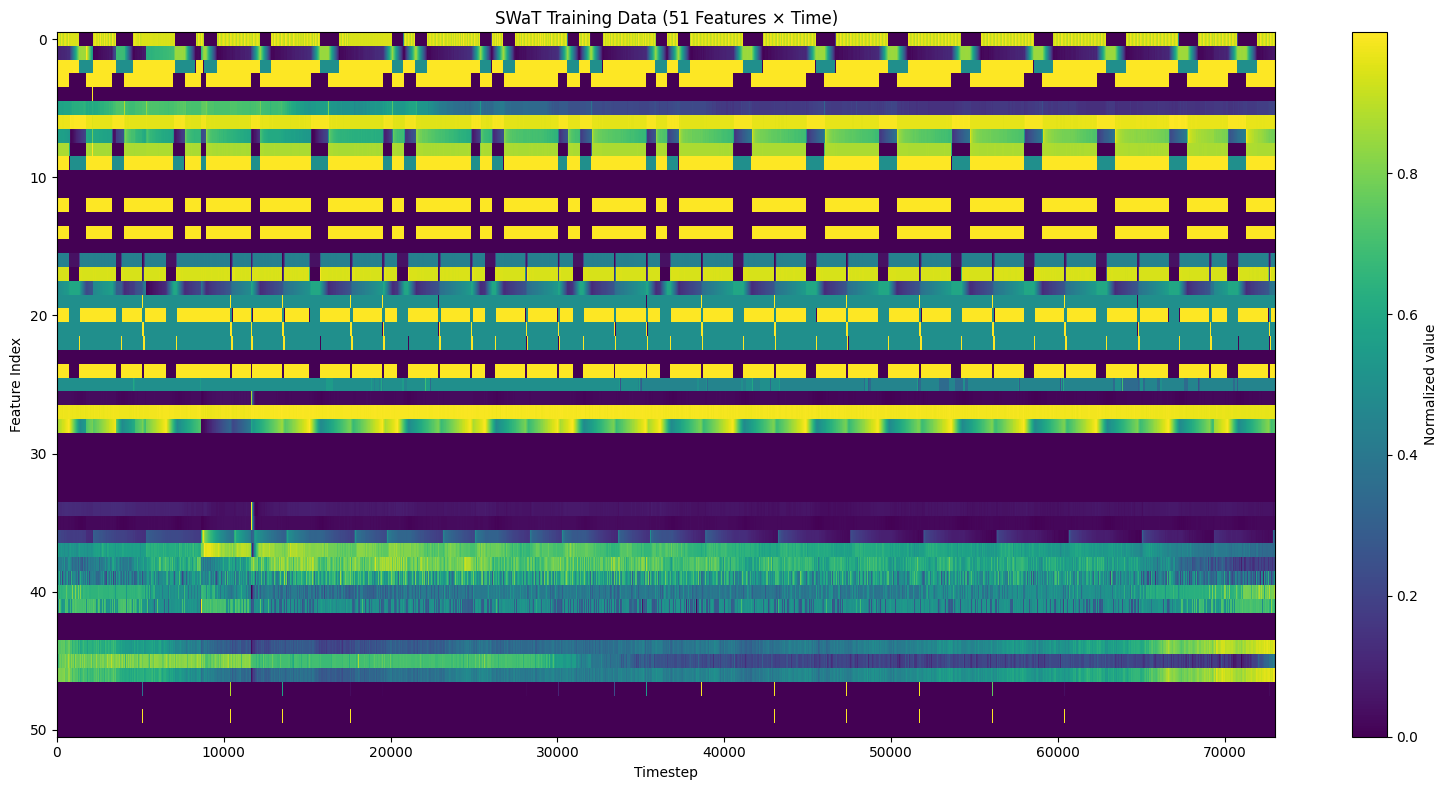

In [9]:
train_data, test_data, test_labels = load_processed_swat_data(
    PROJECT_ROOT / "data" / "swat" / "processed"
)

fig, ax = plt.subplots(figsize=(16, 8))

im = ax.imshow(
    train_data.T,
    aspect="auto",
    cmap="viridis",
    interpolation="nearest",
)

ax.set_xlabel("Timestep")
ax.set_ylabel("Feature Index")
ax.set_title("SWaT Training Data (51 Features × Time)")

plt.colorbar(im, ax=ax, label="Normalized value")
plt.tight_layout()
plt.show()

## Test Data with Ground Truth Anomalies

Plot 4 selected features from the test set with anomaly labels overlaid as red shading.

Test labels shape: (154621,)
Anomaly rate: 35.33% of test timesteps


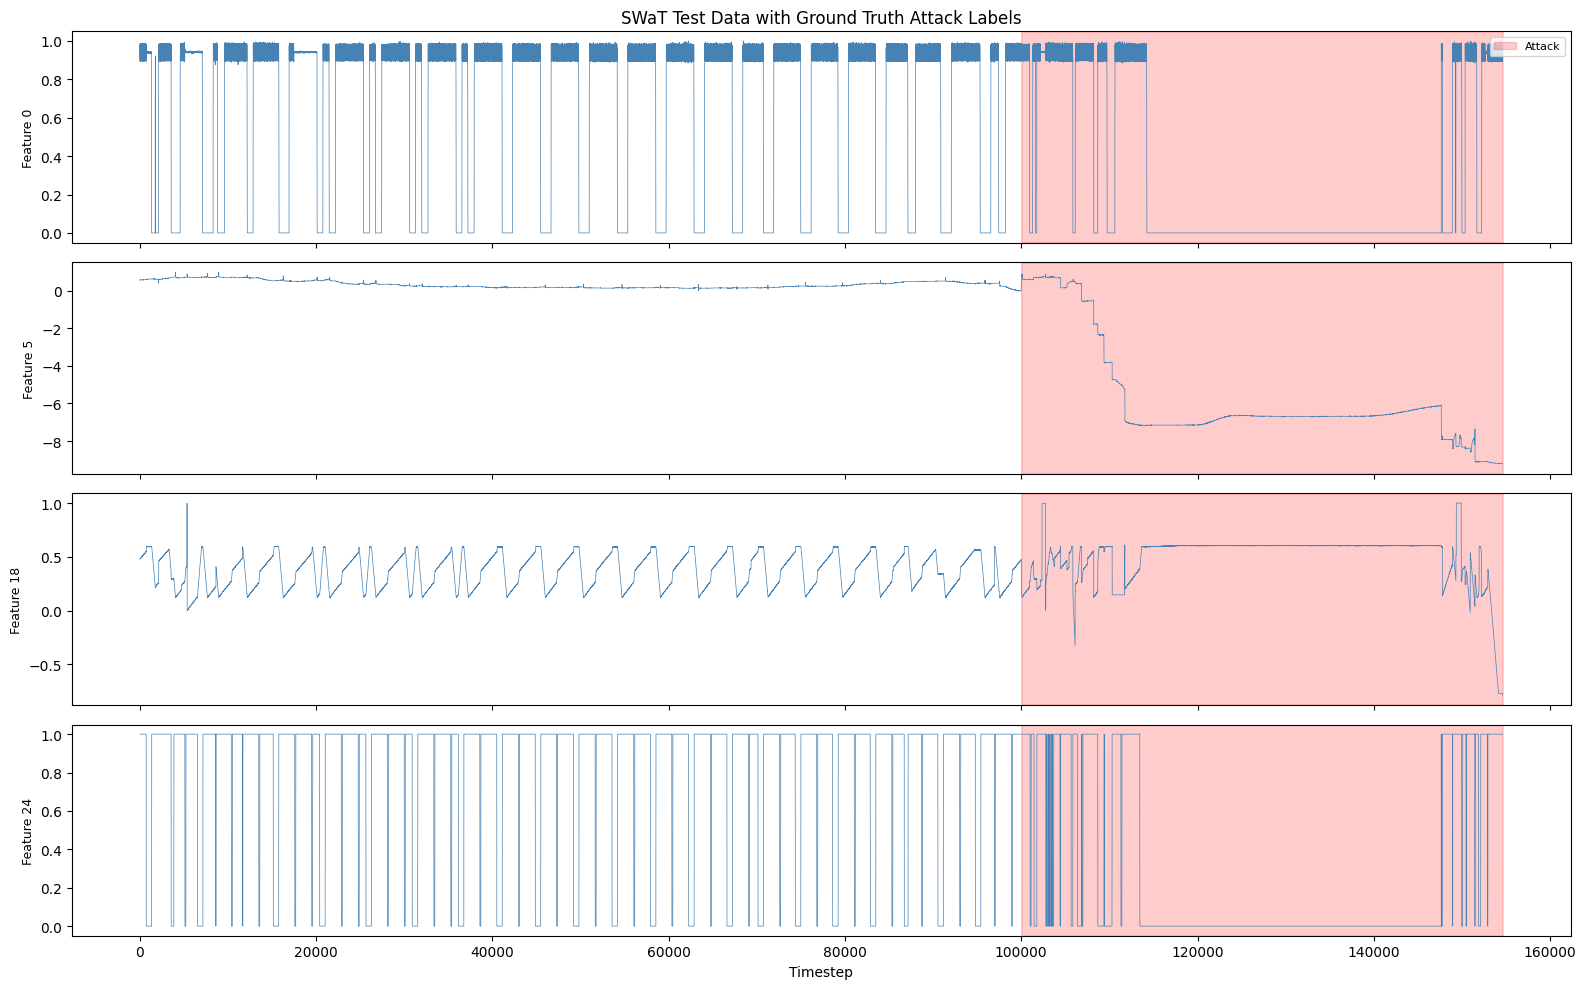

In [10]:
print(f"Test labels shape: {test_labels.shape}")
print(f"Anomaly rate: {test_labels.mean():.2%} of test timesteps")

# Select 4 SWaT features that show useful variation
selected_features = [0, 5, 18, 24]

fig, axes = plt.subplots(4, 1, figsize=(16, 10), sharex=True)

for ax, fidx in zip(axes, selected_features):
    ax.plot(test_data[:, fidx], linewidth=0.5, color="steelblue")
    ax.fill_between(
        range(len(test_data)),
        0,
        1,
        where=test_labels > 0,
        alpha=0.2,
        color="red",
        transform=ax.get_xaxis_transform(),
        label="Attack" if fidx == selected_features[0] else None,
    )
    ax.set_ylabel(f"Feature {fidx}", fontsize=9)

axes[0].set_title("SWaT Test Data with Ground Truth Attack Labels")
axes[0].legend(loc="upper right", fontsize=8)
axes[-1].set_xlabel("Timestep")

plt.tight_layout()
plt.show()

## Feature Correlation Matrix

Compute the Pearson correlation matrix on training data. Correlated feature groups reveal the multivariate structure that TranAD learns to model.

Note: 14 constant feature(s) excluded from correlation analysis


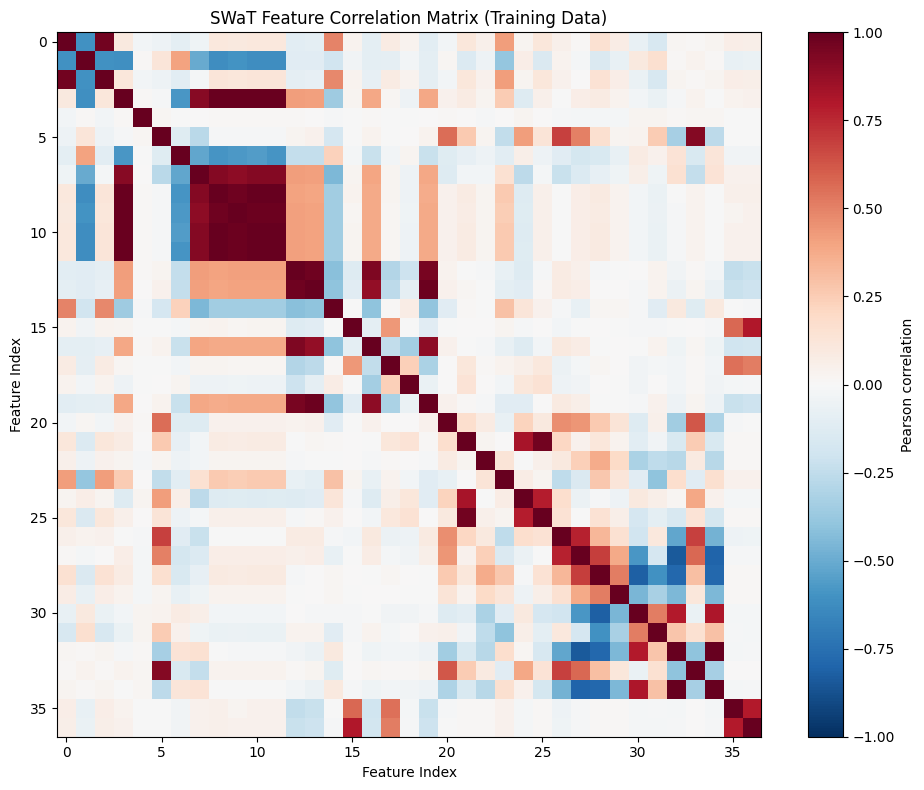

Highly correlated feature pairs (|r| > 0.7): 37


In [11]:
# Filter out constant features (zero variance) to avoid NaN correlations
feature_std = train_data.std(axis=0)
varying_features = np.where(feature_std > 0)[0]

n_constant = train_data.shape[1] - len(varying_features)
if n_constant > 0:
    print(f"Note: {n_constant} constant feature(s) excluded from correlation analysis")

corr = np.corrcoef(train_data[:, varying_features].T)

fig, ax = plt.subplots(figsize=(10, 8))

im = ax.imshow(
    corr,
    cmap="RdBu_r",
    vmin=-1,
    vmax=1,
)

ax.set_xlabel("Feature Index")
ax.set_ylabel("Feature Index")
ax.set_title("SWaT Feature Correlation Matrix (Training Data)")

plt.colorbar(im, ax=ax, label="Pearson correlation")
plt.tight_layout()
plt.show()

n_features = corr.shape[0]
n_high_corr = (
    ((np.abs(corr) > 0.7) & (np.eye(n_features) == 0))
    .sum()
    // 2
)

print(f"Highly correlated feature pairs (|r| > 0.7): {n_high_corr}")

## Zoom into Anomaly Segments
SWaT provides ground-truth attack timestamps but not feature-level root-cause labels. This section identifies an attack segment from the test labels and visualizes selected sensor signals around that attack window.

Total attack segments: 1
Selected attack segment 1: timesteps [100000-154620]
Segment length: 54621


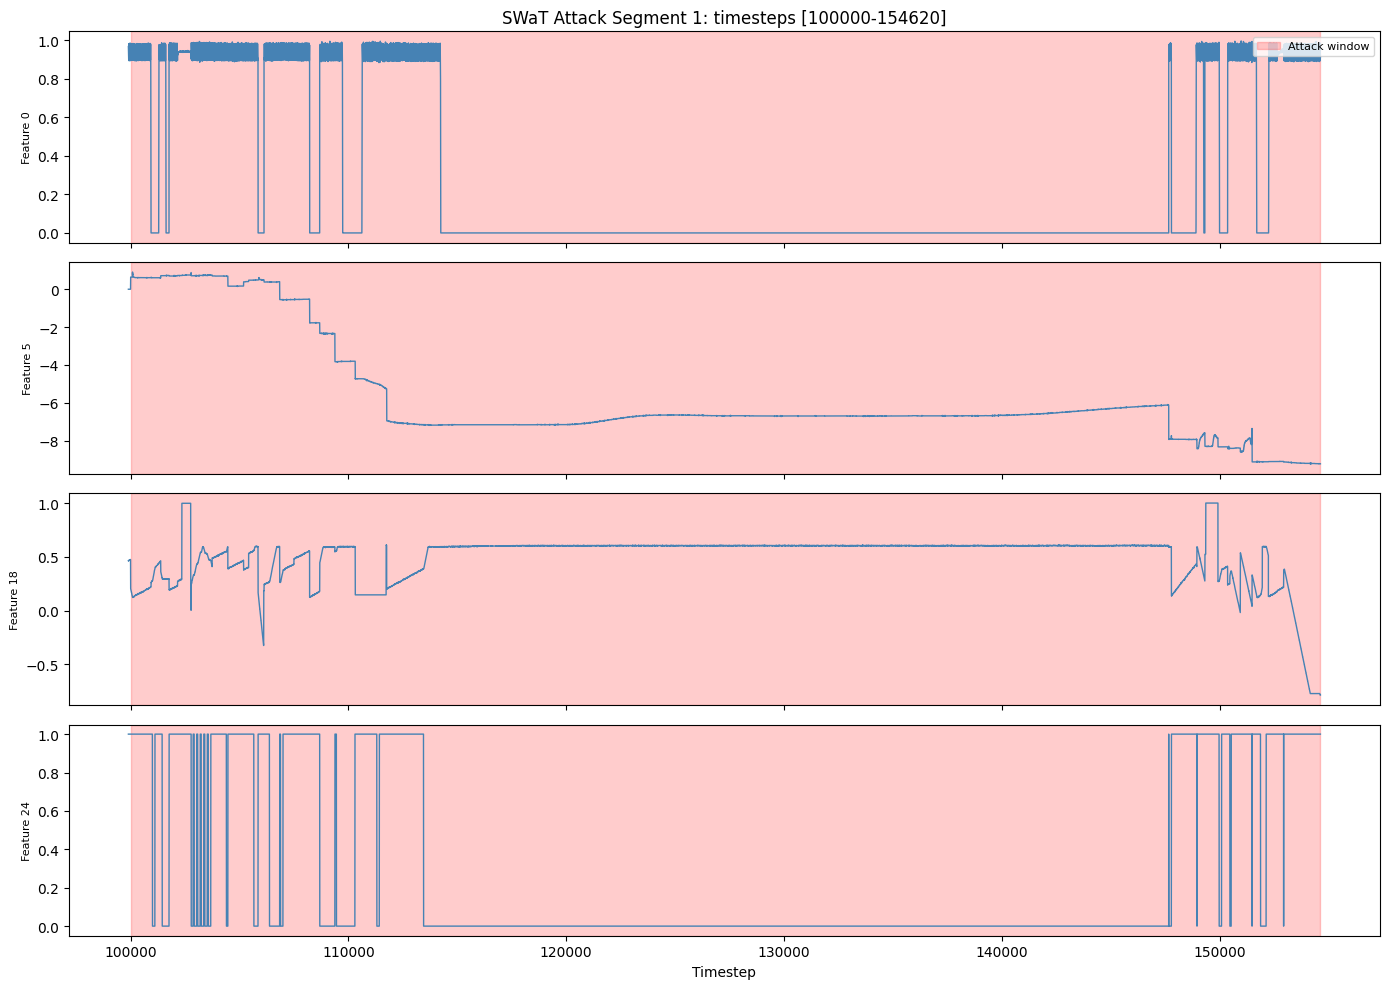

In [12]:
# Find attack segment boundaries from time-level labels
anomaly_binary = (test_labels > 0).astype(int)

padded = np.concatenate([[0], anomaly_binary, [0]])
diffs = np.diff(padded)

starts = np.where(diffs == 1)[0]
ends = np.where(diffs == -1)[0] - 1

print(f"Total attack segments: {len(starts)}")

# Choose the longest attack segment
segment_lengths = ends - starts + 1
best_seg = np.argmax(segment_lengths)

s, e = starts[best_seg], ends[best_seg]

print(f"Selected attack segment {best_seg + 1}: timesteps [{s}-{e}]")
print(f"Segment length: {e - s + 1}")

# Plot selected features around this attack segment
context = 100
view_s = max(0, s - context)
view_e = min(len(test_data), e + context + 1)

selected_features = [0, 5, 18, 24]

fig, axes = plt.subplots(
    len(selected_features),
    1,
    figsize=(14, 2.5 * len(selected_features)),
    sharex=True,
)

if len(selected_features) == 1:
    axes = [axes]

for ax, fidx in zip(axes, selected_features):
    ax.plot(
        range(view_s, view_e),
        test_data[view_s:view_e, fidx],
        linewidth=1,
        color="steelblue",
    )
    ax.axvspan(s, e, alpha=0.2, color="red", label="Attack window")
    ax.set_ylabel(f"Feature {fidx}", fontsize=8)

axes[0].set_title(
    f"SWaT Attack Segment {best_seg + 1}: timesteps [{s}-{e}]"
)
axes[0].legend(loc="upper right", fontsize=8)
axes[-1].set_xlabel("Timestep")

plt.tight_layout()
plt.show()

## Why Multivariate Anomaly Detection?

Industrial control systems consist of many interconnected sensors and actuators that operate together to maintain a safe process. A sudden change in a single sensor reading is not necessarily abnormal. For example, an increase in water flow may be expected when a valve opens. However, the same increase while the valve remains closed or while related sensors remain unchanged may indicate a malfunction or cyberattack.

This is why anomaly detection in industrial systems requires a **multivariate approach** that learns relationships between multiple process variables. Simple univariate thresholds cannot capture these cross-feature dependencies.

Reconstruction-based models such as **TranAD** learn what normal combinations of sensor and actuator values look like during standard operation. During inference, the model attempts to reconstruct each timestep from its surrounding context. Large reconstruction errors indicate that the observed system behavior deviates from learned normal operating patterns, even when individual sensor readings appear reasonable on their own.

## Summary

The SWaT dataset captures the behavior of a real-world industrial water treatment process through 51 interconnected sensors and actuators. The data exhibits strong multivariate relationships, where normal operation depends on coordinated interactions between multiple process variables.

Attack scenarios often disrupt these relationships rather than simply causing extreme values in individual sensors. As a result, effective anomaly detection requires models that learn the underlying system dynamics and cross-feature dependencies.

Transformer-based reconstruction models such as **TranAD** are well suited for this task because they learn normal multivariate operating patterns and identify deviations through reconstruction error. This enables the detection of complex attacks and abnormal process behavior that may not be visible through simple threshold-based monitoring.